Тема: «Исследование и сравнение методов понижения размерности и кластеризации на реальном высокоразмерном датасете (из области по выбору: биоинформатика, тексты, изображения, графы) с анализом устойчивости и интерпретируемости полученных кластеров».[7][5] 

Основные требования к проекту: Выбор и обоснование одного или двух реальных высокоразмерных датасетов (например, single‑cell RNA‑seq, embedding‑представления текстов, feature‑описания изображений).[2][5] 

Построение и сравнение нескольких пайплайнов «DR → кластеризация» (минимум 3 DR‑метода и 3 алгоритма кластеризации) с оценкой качества, устойчивости и практической интерпретации кластеров.[4][12][7]

In [11]:
#%pip install -q kagglehub umap-learn


Note: you may need to restart the kernel to use updated packages.


In [5]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    v_measure_score
)

from sklearn.metrics.pairwise import cosine_distances

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [7]:
import kagglehub
dataset_path = kagglehub.dataset_download("jacopoferretti/bbc-articles-dataset")
print("Путь к датасету:", dataset_path)

csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
csv_files

Путь к датасету: C:\Users\tchag\.cache\kagglehub\datasets\jacopoferretti\bbc-articles-dataset\versions\16


['C:\\Users\\tchag\\.cache\\kagglehub\\datasets\\jacopoferretti\\bbc-articles-dataset\\versions\\16\\bbc_news_text_complexity_summarization.csv',
 'C:\\Users\\tchag\\.cache\\kagglehub\\datasets\\jacopoferretti\\bbc-articles-dataset\\versions\\16\\archive\\bbc_text_cls.csv',
 'C:\\Users\\tchag\\.cache\\kagglehub\\datasets\\jacopoferretti\\bbc-articles-dataset\\versions\\16\\archive (2)\\bbc-news-data.csv']

In [9]:
def find_text_label_columns(df):
    text_candidates = [
        "text", "article", "content", "body", "news", "description",
        "Text", "Article", "Content", "Body", "News"
    ]
    label_candidates = [
        "label", "category", "class", "target", "topic",
        "Label", "Category", "Class", "Target", "Topic"
    ]

    text_col = None
    label_col = None

    for col in df.columns:
        if col in text_candidates:
            text_col = col
            break

    for col in df.columns:
        if col in label_candidates:
            label_col = col
            break

    if text_col is None:
        object_cols = df.select_dtypes(include="object").columns.tolist()
        if object_cols:
            text_col = max(object_cols, key=lambda c: df[c].astype(str).str.len().mean())

    if label_col is None:
        object_cols = df.select_dtypes(include="object").columns.tolist()
        possible_labels = [
            c for c in object_cols
            if c != text_col and df[c].nunique() <= 30
        ]
        if possible_labels:
            label_col = possible_labels[0]

    return text_col, label_col


loaded = False

for file in csv_files:
    try:
        temp = pd.read_csv(file)
        text_col, label_col = find_text_label_columns(temp)

        if text_col is not None and label_col is not None:
            df = temp[[text_col, label_col]].copy()
            df.columns = ["text", "label"]
            loaded = True
            print("Использован файл:", file)
            print("Текстовый столбец:", text_col)
            print("Столбец меток:", label_col)
            break

    except Exception as e:
        print("Не удалось прочитать:", file, e)

if not loaded:
    raise ValueError("Не удалось автоматически найти CSV с текстом и метками.")

df = df.dropna()
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(str)

df.head()

Использован файл: C:\Users\tchag\.cache\kagglehub\datasets\jacopoferretti\bbc-articles-dataset\versions\16\bbc_news_text_complexity_summarization.csv
Текстовый столбец: text
Столбец меток: labels


,text,label
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


Размер датасета: (2127, 2)
Количество классов: 5
Классы: ['business', 'entertainment', 'politics', 'sport', 'tech']


label
sport            505
business         503
politics         403
entertainment    369
tech             347
Name: count, dtype: int64

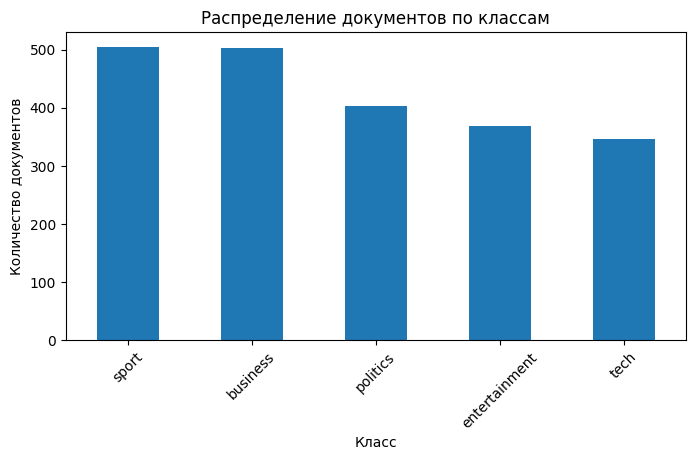

In [11]:
print("Размер датасета:", df.shape)
print("Количество классов:", df["label"].nunique())
print("Классы:", sorted(df["label"].unique()))

class_counts = df["label"].value_counts()
display(class_counts)

class_counts.plot(kind="bar", figsize=(8, 4))
plt.title("Распределение документов по классам")
plt.xlabel("Класс")
plt.ylabel("Количество документов")
plt.xticks(rotation=45)
plt.show()

Для финального проекта выбран текстовый датасет BBC Articles / BBC News. 
Каждый объект — новостная статья, а целевая метка — тематическая категория статьи. 
Датасет подходит для исследования методов понижения размерности и кластеризации, 
поскольку после TF-IDF-векторизации каждый текст представляется в виде высокоразмерного 
разреженного вектора. 

Задача проекта — проверить, насколько методы понижения размерности позволяют сохранить 
семантическую структуру текстов, и какие алгоритмы кластеризации лучше выделяют тематические группы.

In [14]:
MAX_FEATURES = 5000

vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=2,
    max_df=0.85,
    stop_words="english",
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["text"])
feature_names = np.array(vectorizer.get_feature_names_out())

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["label"])
target_names = label_encoder.classes_

print("Размер TF-IDF матрицы:", X.shape)
print("Количество ненулевых элементов:", X.nnz)
print("Доля ненулевых элементов:", X.nnz / (X.shape[0] * X.shape[1]))
print("Классы:", target_names)

Размер TF-IDF матрицы: (2127, 5000)
Количество ненулевых элементов: 251455
Доля ненулевых элементов: 0.023644099670897978
Классы: ['business' 'entertainment' 'politics' 'sport' 'tech']


In [16]:
def reduce_dimensions(X, method, n_components=10, random_state=42):
    if method == "SVD":
        model = TruncatedSVD(
            n_components=n_components,
            random_state=random_state
        )
        Z = model.fit_transform(X)

    elif method == "NMF":
        model = NMF(
            n_components=n_components,
            init="nndsvda",
            random_state=random_state,
            max_iter=500
        )
        Z = model.fit_transform(X)

    elif method == "UMAP":
        import umap.umap_ as umap

        model = umap.UMAP(
            n_components=n_components,
            n_neighbors=15,
            min_dist=0.1,
            metric="cosine",
            random_state=random_state
        )
        Z = model.fit_transform(X)

    else:
        raise ValueError(f"Неизвестный метод DR: {method}")

    return Z, model

In [18]:
def cluster_embedding(Z, algorithm, n_clusters, random_state=42):
    if algorithm == "KMeans":
        model = KMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init=20
        )
        labels = model.fit_predict(Z)

    elif algorithm == "Agglomerative":
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage="ward"
        )
        labels = model.fit_predict(Z)

    elif algorithm == "BIRCH":
        model = Birch(
            n_clusters=n_clusters
        )
        labels = model.fit_predict(Z)

    else:
        raise ValueError(f"Неизвестный алгоритм кластеризации: {algorithm}")

    return labels, model

In [20]:
def evaluate_clustering(Z, labels, y_true):
    result = {}

    unique_labels = np.unique(labels)

    if len(unique_labels) > 1:
        result["Silhouette"] = silhouette_score(
            Z,
            labels,
            sample_size=min(1000, len(Z)),
            random_state=RANDOM_STATE
        )
        result["Calinski_Harabasz"] = calinski_harabasz_score(Z, labels)
        result["Davies_Bouldin"] = davies_bouldin_score(Z, labels)
    else:
        result["Silhouette"] = np.nan
        result["Calinski_Harabasz"] = np.nan
        result["Davies_Bouldin"] = np.nan

    result["ARI"] = adjusted_rand_score(y_true, labels)
    result["AMI"] = adjusted_mutual_info_score(y_true, labels)
    result["V_Measure"] = v_measure_score(y_true, labels)
    result["N_Clusters"] = len(unique_labels)

    return result

In [22]:
dr_methods = ["SVD", "NMF", "UMAP"]
cluster_methods = ["KMeans", "Agglomerative", "BIRCH"]

n_clusters = len(np.unique(y))
n_components = 10

results = []
embeddings = {}
cluster_labels = {}

for dr_name in dr_methods:
    print(f"DR метод: {dr_name}")

    Z, dr_model = reduce_dimensions(
        X,
        method=dr_name,
        n_components=n_components,
        random_state=RANDOM_STATE
    )

    embeddings[dr_name] = Z

    for cluster_name in cluster_methods:
        print(f"  Кластеризация: {cluster_name}")

        labels, cluster_model = cluster_embedding(
            Z,
            algorithm=cluster_name,
            n_clusters=n_clusters,
            random_state=RANDOM_STATE
        )

        cluster_labels[(dr_name, cluster_name)] = labels

        metrics = evaluate_clustering(Z, labels, y)

        results.append({
            "DR_Method": dr_name,
            "Clustering": cluster_name,
            **metrics
        })

results_df = pd.DataFrame(results)
results_df

DR метод: SVD
  Кластеризация: KMeans
  Кластеризация: Agglomerative
  Кластеризация: BIRCH
DR метод: NMF
  Кластеризация: KMeans
  Кластеризация: Agglomerative
  Кластеризация: BIRCH
DR метод: UMAP
  Кластеризация: KMeans
  Кластеризация: Agglomerative
  Кластеризация: BIRCH


,DR_Method,Clustering,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI,AMI,V_Measure,N_Clusters
0,SVD,KMeans,0.237581,427.348752,1.404420,0.471366,0.619048,0.619998,5
1,SVD,Agglomerative,0.204280,378.451735,1.483699,0.483053,0.616454,0.617421,5
2,SVD,BIRCH,NaN,NaN,NaN,0.000000,0.000000,0.000000,1
3,NMF,KMeans,0.347760,448.385464,0.929219,0.123245,0.379568,0.381338,5
4,NMF,Agglomerative,0.314757,389.460235,0.880307,0.098183,0.332599,0.334611,5
5,NMF,BIRCH,NaN,NaN,NaN,0.000000,0.000000,0.000000,1
6,UMAP,KMeans,0.492182,2605.920166,0.738150,0.830154,0.791935,0.792427,5
7,UMAP,Agglomerative,0.488030,2566.090332,0.743825,0.832903,0.799031,0.799506,5
8,UMAP,BIRCH,0.477555,2506.903320,0.765321,0.789770,0.765539,0.766094,5


In [23]:
display(
    results_df.sort_values(
        by=["ARI", "Silhouette"],
        ascending=False
    )
)

results_df.set_index(["DR_Method", "Clustering"])[
    ["Silhouette", "Calinski_Harabasz", "Davies_Bouldin", "ARI", "AMI", "V_Measure"]
].round(4)

,DR_Method,Clustering,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI,AMI,V_Measure,N_Clusters
7,UMAP,Agglomerative,0.488030,2566.090332,0.743825,0.832903,0.799031,0.799506,5
6,UMAP,KMeans,0.492182,2605.920166,0.738150,0.830154,0.791935,0.792427,5
8,UMAP,BIRCH,0.477555,2506.903320,0.765321,0.789770,0.765539,0.766094,5
1,SVD,Agglomerative,0.204280,378.451735,1.483699,0.483053,0.616454,0.617421,5
0,SVD,KMeans,0.237581,427.348752,1.404420,0.471366,0.619048,0.619998,5
3,NMF,KMeans,0.347760,448.385464,0.929219,0.123245,0.379568,0.381338,5
4,NMF,Agglomerative,0.314757,389.460235,0.880307,0.098183,0.332599,0.334611,5
2,SVD,BIRCH,NaN,NaN,NaN,0.000000,0.000000,0.000000,1
5,NMF,BIRCH,NaN,NaN,NaN,0.000000,0.000000,0.000000,1


Silhouette  Calinski_Harabasz  Davies_Bouldin  \
DR_Method Clustering                                                     
SVD       KMeans             0.2376           427.3488          1.4044   
          Agglomerative      0.2043           378.4517          1.4837   
          BIRCH                 NaN                NaN             NaN   
NMF       KMeans             0.3478           448.3855          0.9292   
          Agglomerative      0.3148           389.4602          0.8803   
          BIRCH                 NaN                NaN             NaN   
UMAP      KMeans             0.4922          2605.9202          0.7381   
          Agglomerative      0.4880          2566.0903          0.7438   
          BIRCH              0.4776          2506.9033          0.7653   

                            ARI     AMI  V_Measure  
DR_Method Clustering                                
SVD       KMeans         0.4714  0.6190     0.6200  
          Agglomerative  0.4831  0.6165     0.6174  
          BIRCH          0.0000  0.0000     0.0000  
NMF       KMeans         0.1232  0.3796     0.3813  
          Agglomerative  0.0982  0.3326     0.3346  
          BIRCH          0.0000  0.0000     0.0000  
UMAP      KMeans         0.8302  0.7919     0.7924  
          Agglomerative  0.8329  0.7990     0.7995  
          BIRCH          0.7898  0.7655     0.7661

In [24]:
def create_composite_score(results_df):
    df_score = results_df.copy()

    weights = {
        "Silhouette": 0.20,
        "Calinski_Harabasz": 0.10,
        "Davies_Bouldin": -0.10,
        "ARI": 0.30,
        "AMI": 0.20,
        "V_Measure": 0.10
    }

    normalized_columns = []

    for metric, weight in weights.items():
        values = df_score[metric].astype(float)
        min_val = values.min()
        max_val = values.max()

        if max_val == min_val:
            df_score[metric + "_norm"] = 0.5
        else:
            if weight > 0:
                df_score[metric + "_norm"] = (values - min_val) / (max_val - min_val)
            else:
                df_score[metric + "_norm"] = (max_val - values) / (max_val - min_val)

        normalized_columns.append(metric + "_norm")

    total_weight = sum(abs(w) for w in weights.values())

    df_score["Composite_Score"] = sum(
        df_score[metric + "_norm"] * abs(weight)
        for metric, weight in weights.items()
    ) / total_weight

    return df_score.sort_values("Composite_Score", ascending=False)

ranked_results = create_composite_score(results_df)

ranked_results[
    [
        "DR_Method",
        "Clustering",
        "Silhouette",
        "Calinski_Harabasz",
        "Davies_Bouldin",
        "ARI",
        "AMI",
        "V_Measure",
        "Composite_Score"
    ]
].round(4)

,DR_Method,Clustering,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI,AMI,V_Measure,Composite_Score
6,UMAP,KMeans,0.4922,2605.9202,0.7381,0.8302,0.7919,0.7924,0.9963
7,UMAP,Agglomerative,0.4880,2566.0903,0.7438,0.8329,0.7990,0.7995,0.9946
8,UMAP,BIRCH,0.4776,2506.9033,0.7653,0.7898,0.7655,0.7661,0.9537
0,SVD,KMeans,0.2376,427.3488,1.4044,0.4714,0.6190,0.6200,0.4382
1,SVD,Agglomerative,0.2043,378.4517,1.4837,0.4831,0.6165,0.6174,0.4055
3,NMF,KMeans,0.3478,448.3855,0.9292,0.1232,0.3796,0.3813,0.3643
4,NMF,Agglomerative,0.3148,389.4602,0.8803,0.0982,0.3326,0.3346,0.3186
2,SVD,BIRCH,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN
5,NMF,BIRCH,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN


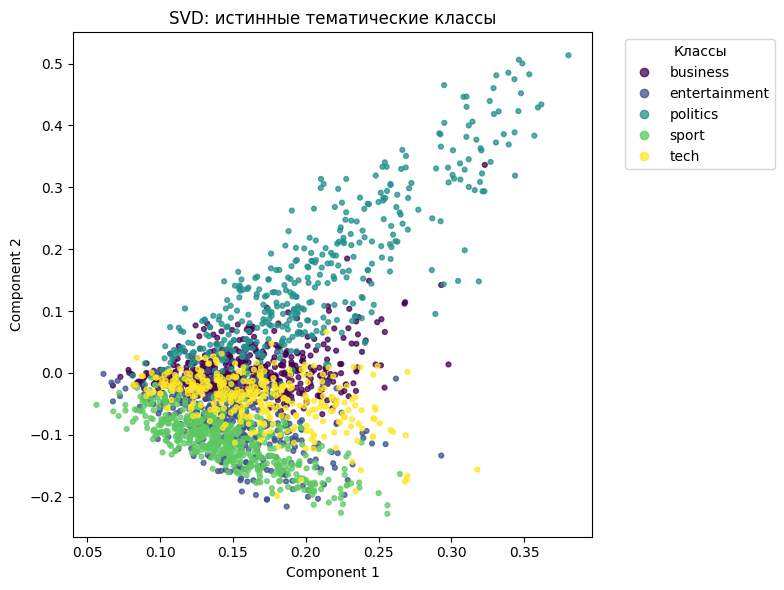

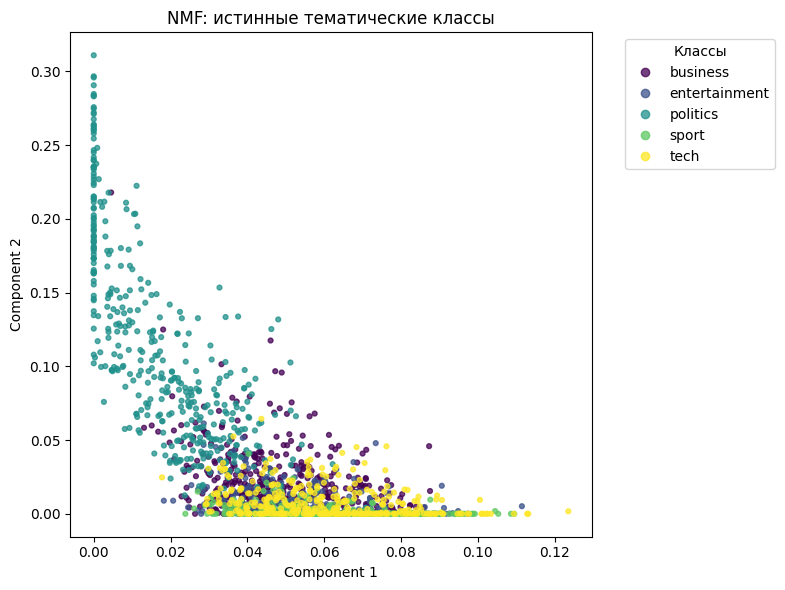

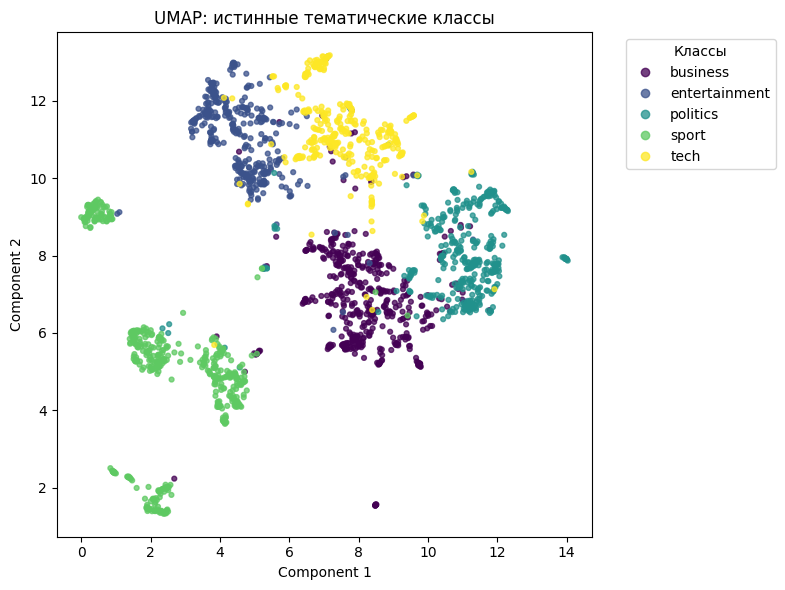

In [25]:
def plot_2d_projection(Z, color_values, title, label_names=None):
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        Z[:, 0],
        Z[:, 1],
        c=color_values,
        s=12,
        alpha=0.75
    )

    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    if label_names is not None:
        handles, _ = scatter.legend_elements()
        plt.legend(
            handles,
            label_names,
            title="Классы",
            bbox_to_anchor=(1.05, 1),
            loc="upper left"
        )

    plt.tight_layout()
    plt.show()


for dr_name in dr_methods:
    Z2, _ = reduce_dimensions(
        X,
        method=dr_name,
        n_components=2,
        random_state=RANDOM_STATE
    )

    plot_2d_projection(
        Z2,
        y,
        f"{dr_name}: истинные тематические классы",
        label_names=target_names
    )

Лучший пайплайн:
UMAP → KMeans


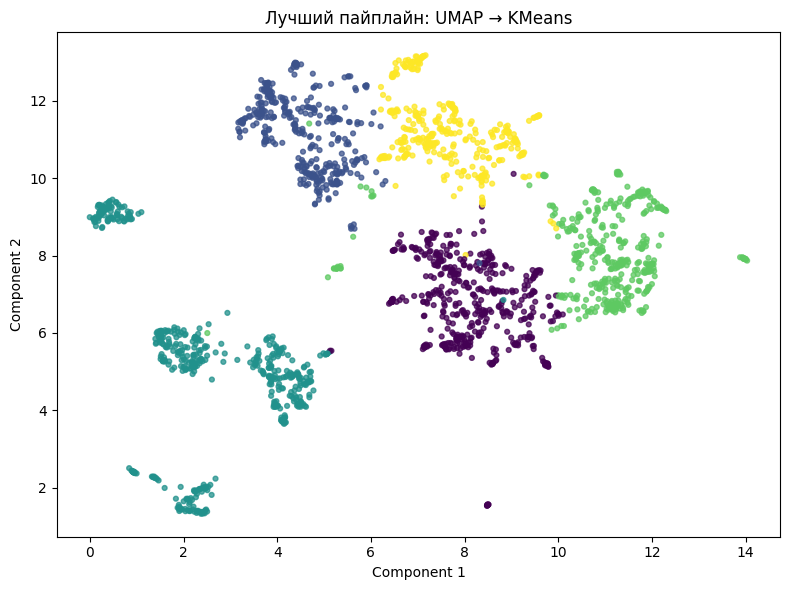

In [30]:
best_row = ranked_results.iloc[0]
best_dr = best_row["DR_Method"]
best_cluster = best_row["Clustering"]

print("Лучший пайплайн:")
print(best_dr, "→", best_cluster)

Z2_best, _ = reduce_dimensions(
    X,
    method=best_dr,
    n_components=2,
    random_state=RANDOM_STATE
)

best_labels, _ = cluster_embedding(
    embeddings[best_dr],
    algorithm=best_cluster,
    n_clusters=n_clusters,
    random_state=RANDOM_STATE
)

plot_2d_projection(
    Z2_best,
    best_labels,
    f"Лучший пайплайн: {best_dr} → {best_cluster}"
)

Используемые метрики: ['Silhouette', 'Calinski_Harabasz', 'Davies_Bouldin', 'ARI', 'AMI', 'V_Measure']


,DR_Method,Algorithm,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI,AMI,V_Measure,N_Clusters
0,SVD,KMeans,0.237581,427.348752,1.404420,0.471366,0.619048,0.619998,5
1,SVD,Agglomerative,0.204280,378.451735,1.483699,0.483053,0.616454,0.617421,5
2,SVD,BIRCH,NaN,NaN,NaN,0.000000,0.000000,0.000000,1
3,NMF,KMeans,0.347760,448.385464,0.929219,0.123245,0.379568,0.381338,5
4,NMF,Agglomerative,0.314757,389.460235,0.880307,0.098183,0.332599,0.334611,5


Рейтинг пайплайнов по средней нормализованной оценке:


,DR_Method,Algorithm,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI,AMI,V_Measure,Mean_Normalized_Score
6,UMAP,KMeans,0.4922,2605.9202,0.7381,0.8302,0.7919,0.7924,0.9965
7,UMAP,Agglomerative,0.4880,2566.0903,0.7438,0.8329,0.7990,0.7995,0.9933
8,UMAP,BIRCH,0.4776,2506.9033,0.7653,0.7898,0.7655,0.7661,0.9555
3,NMF,KMeans,0.3478,448.3855,0.9292,0.1232,0.3796,0.3813,0.3956
0,SVD,KMeans,0.2376,427.3488,1.4044,0.4714,0.6190,0.6200,0.3934
4,NMF,Agglomerative,0.3148,389.4602,0.8803,0.0982,0.3326,0.3346,0.3584
1,SVD,Agglomerative,0.2043,378.4517,1.4837,0.4831,0.6165,0.6174,0.3540
2,SVD,BIRCH,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000
5,NMF,BIRCH,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000


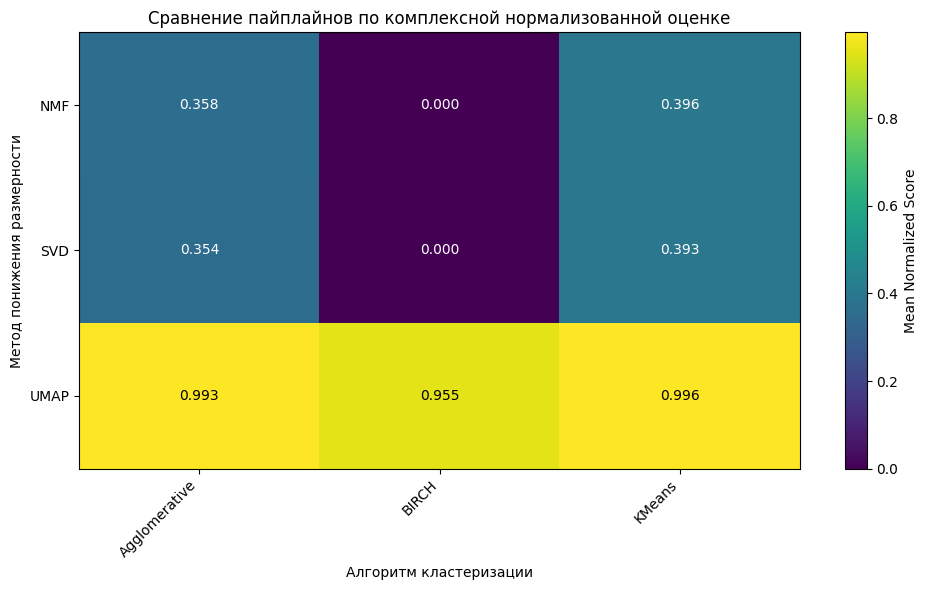

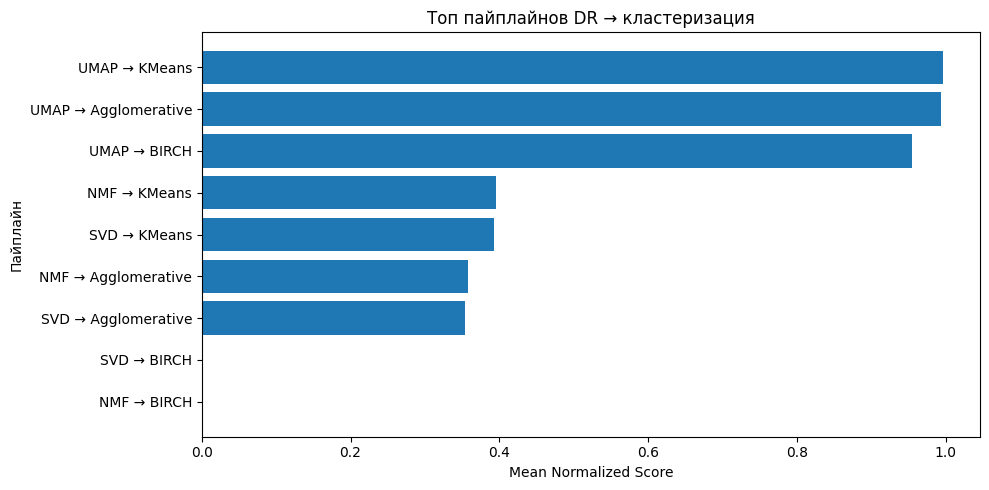

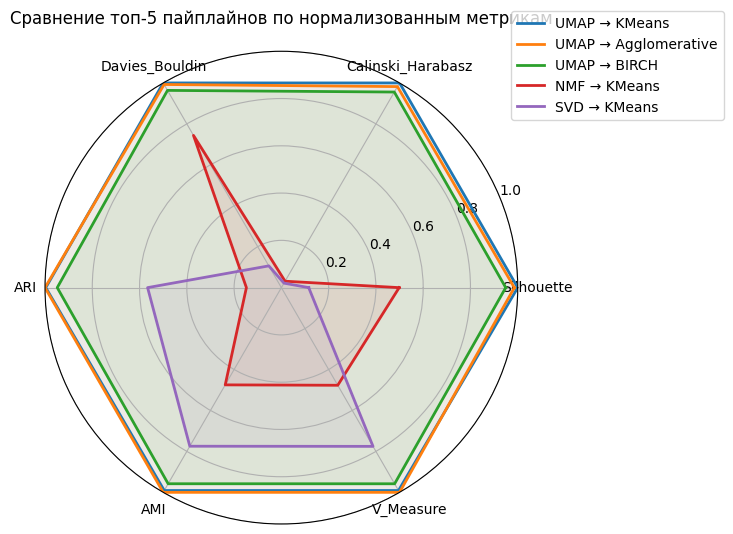

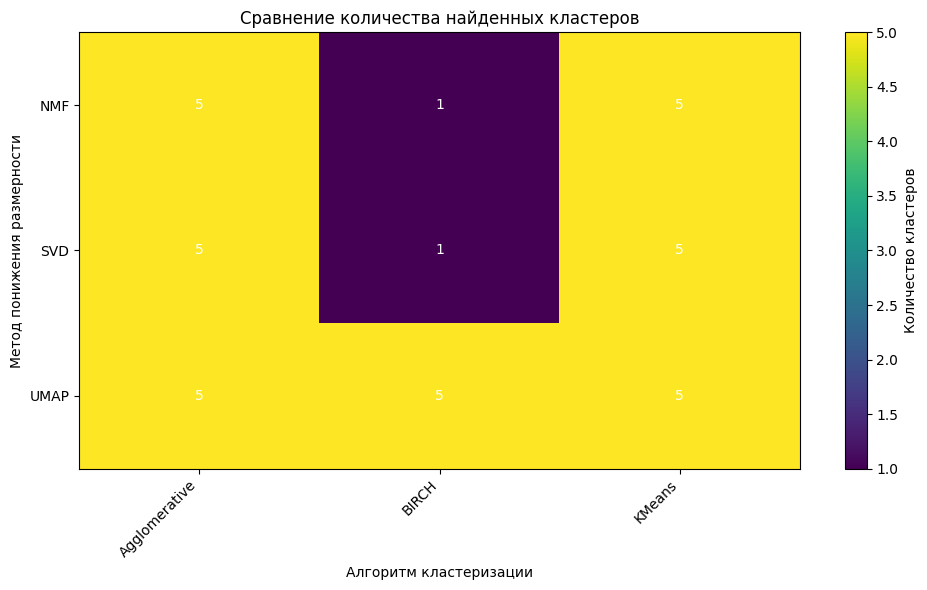

,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI,AMI,V_Measure
DR_Method,,,,,,
NMF,0.3313,418.9228,0.9048,0.0738,0.2374,0.2386
SVD,0.2209,402.9002,1.4441,0.3181,0.4118,0.4125
UMAP,0.4859,2559.6379,0.7491,0.8176,0.7855,0.7860


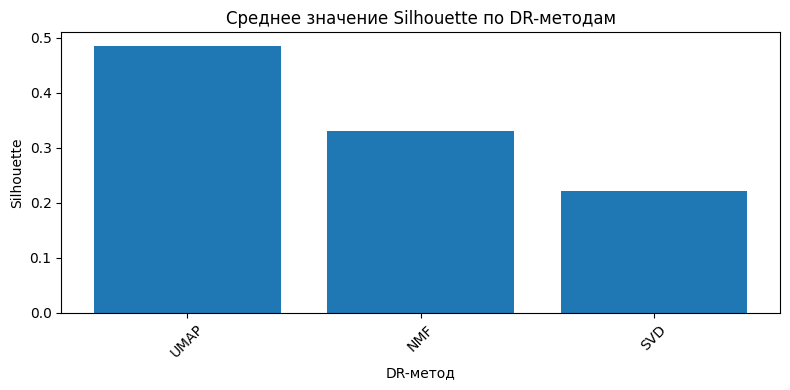

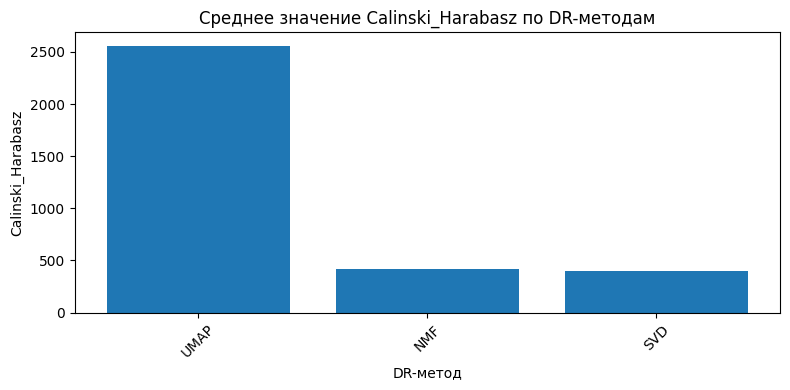

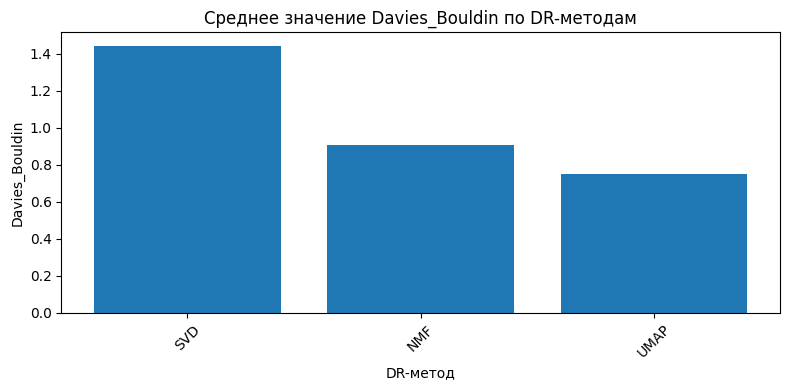

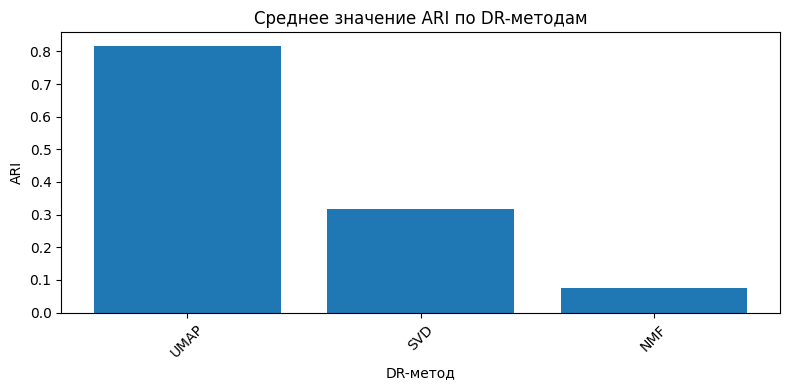

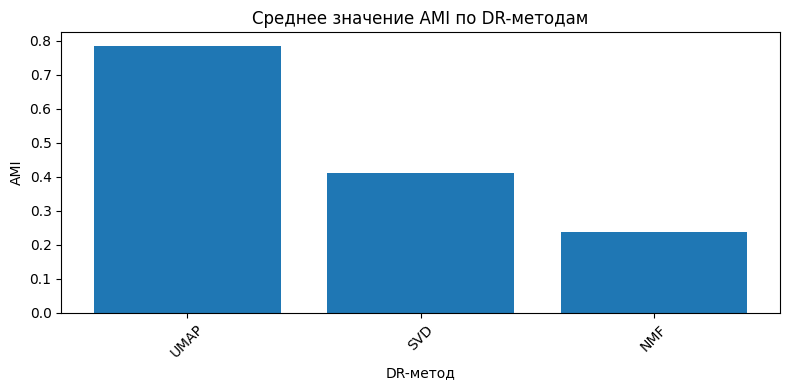

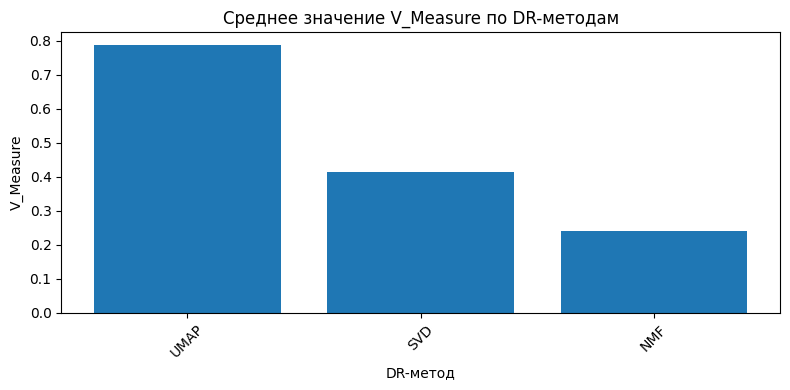

,Silhouette,Calinski_Harabasz,Davies_Bouldin,ARI,AMI,V_Measure
Algorithm,,,,,,
Agglomerative,0.3357,1111.3341,1.0359,0.4714,0.5827,0.5838
BIRCH,0.4776,2506.9033,0.7653,0.2633,0.2552,0.2554
KMeans,0.3592,1160.5515,1.0239,0.4749,0.5969,0.5979


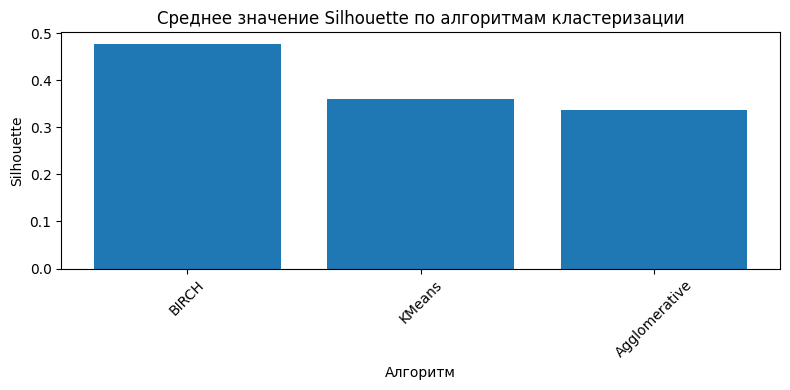

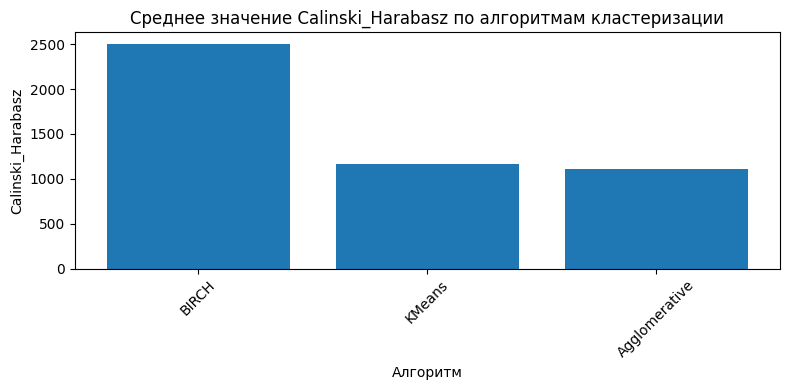

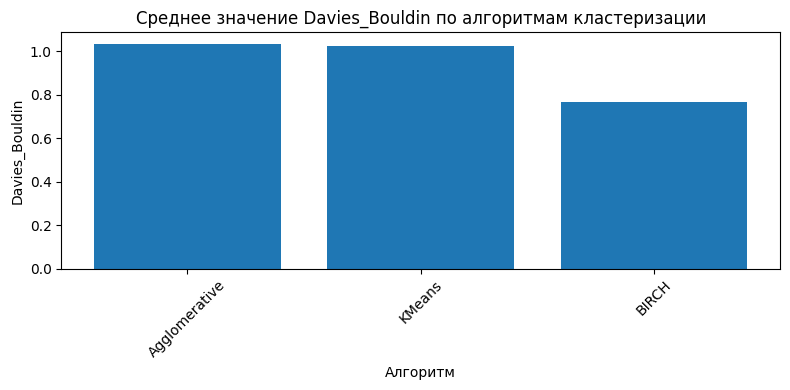

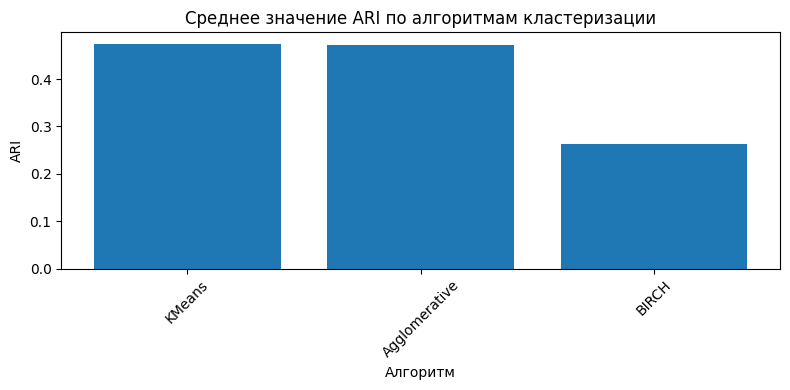

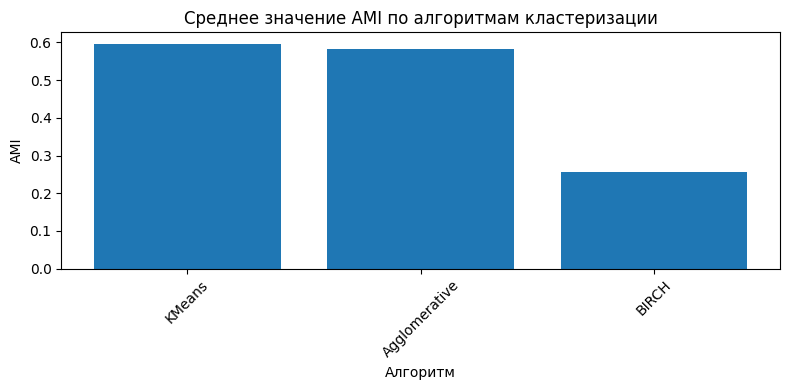

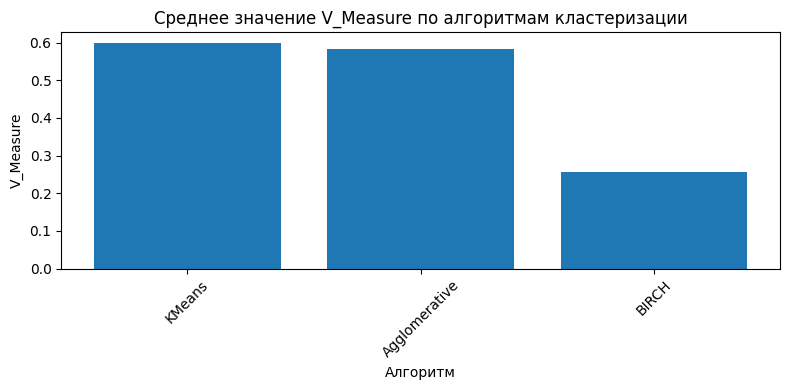

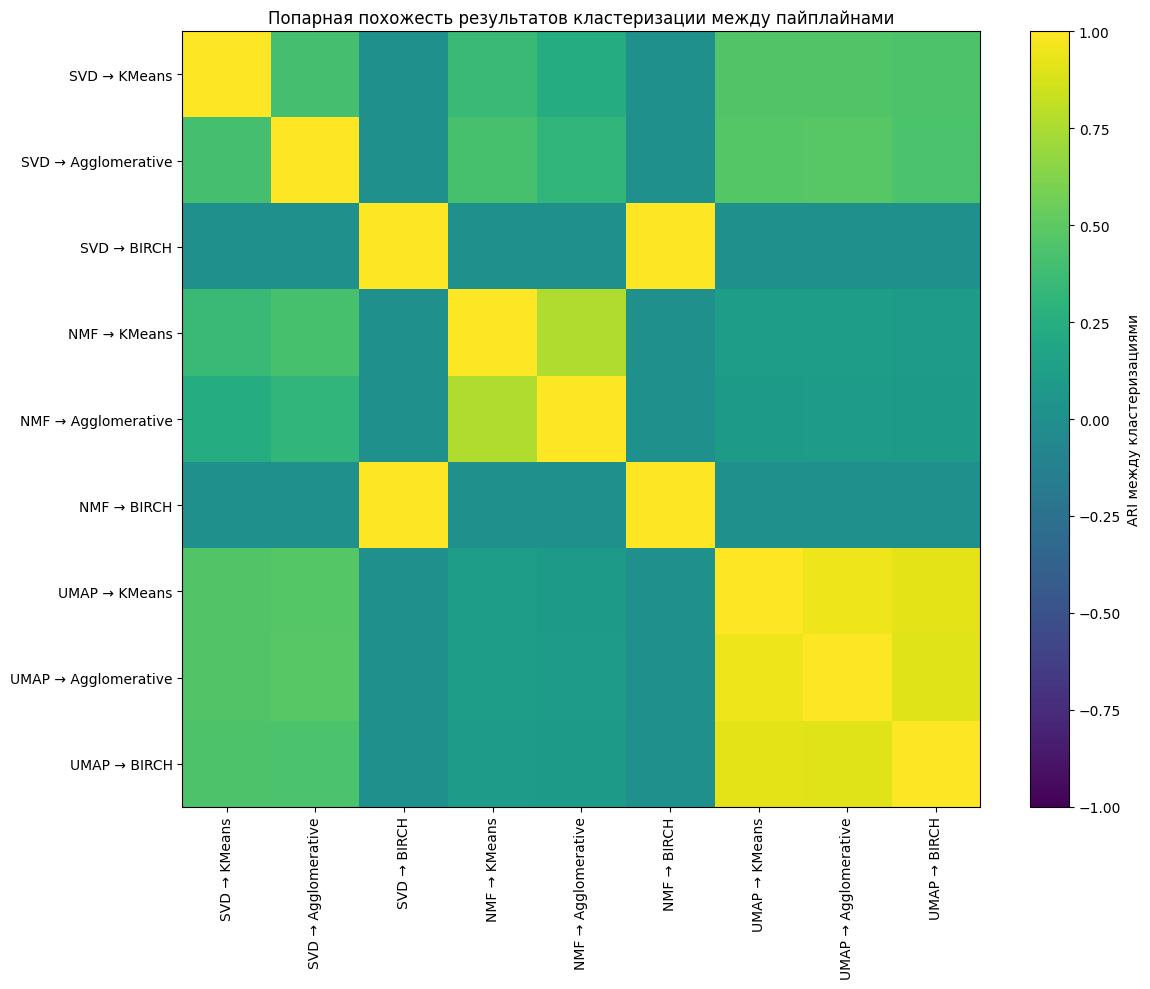

,SVD → KMeans,SVD → Agglomerative,SVD → BIRCH,NMF → KMeans,NMF → Agglomerative,NMF → BIRCH,UMAP → KMeans,UMAP → Agglomerative,UMAP → BIRCH
SVD → KMeans,1.000,0.414,0.0,0.356,0.236,0.0,0.456,0.454,0.439
SVD → Agglomerative,0.414,1.000,0.0,0.420,0.316,0.0,0.475,0.480,0.435
SVD → BIRCH,0.000,0.000,1.0,0.000,0.000,1.0,0.000,0.000,0.000
NMF → KMeans,0.356,0.420,0.0,1.000,0.761,0.0,0.116,0.121,0.103
NMF → Agglomerative,0.236,0.316,0.0,0.761,1.000,0.0,0.093,0.099,0.087
NMF → BIRCH,0.000,0.000,1.0,0.000,0.000,1.0,0.000,0.000,0.000
UMAP → KMeans,0.456,0.475,0.0,0.116,0.093,0.0,1.000,0.947,0.922
UMAP → Agglomerative,0.454,0.480,0.0,0.121,0.099,0.0,0.947,1.000,0.900
UMAP → BIRCH,0.439,0.435,0.0,0.103,0.087,0.0,0.922,0.900,1.000


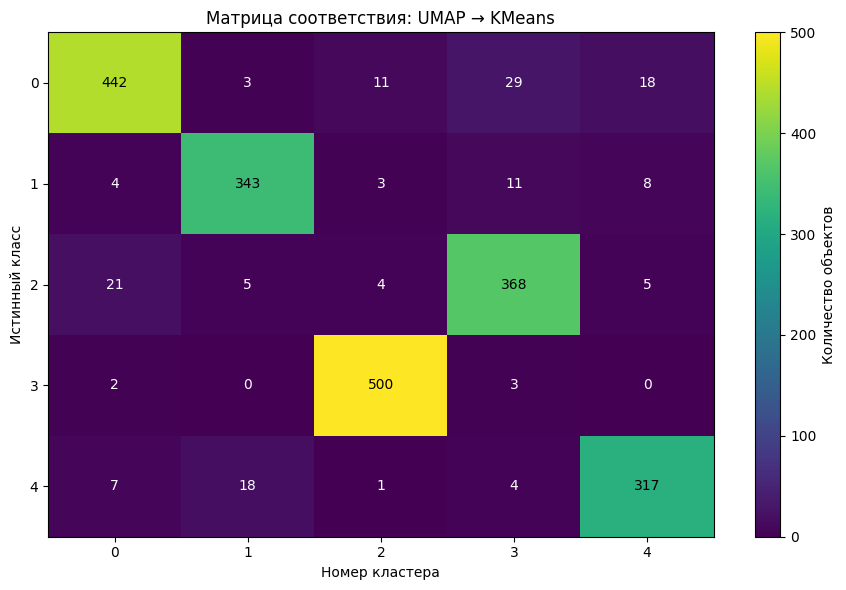

Процентный состав кластеров для лучшего пайплайна: UMAP → KMeans


True_Class,0,1,2,3,4
Cluster,,,,,
0,92.86,0.84,4.41,0.42,1.47
1,0.81,92.95,1.36,0.00,4.88
2,2.12,0.58,0.77,96.34,0.19
3,6.99,2.65,88.67,0.72,0.96
4,5.17,2.30,1.44,0.00,91.09


,DR_Method,Algorithm,Cluster,Size
0,SVD,KMeans,0,174
1,SVD,KMeans,1,483
2,SVD,KMeans,2,399
3,SVD,KMeans,3,887
4,SVD,KMeans,4,184


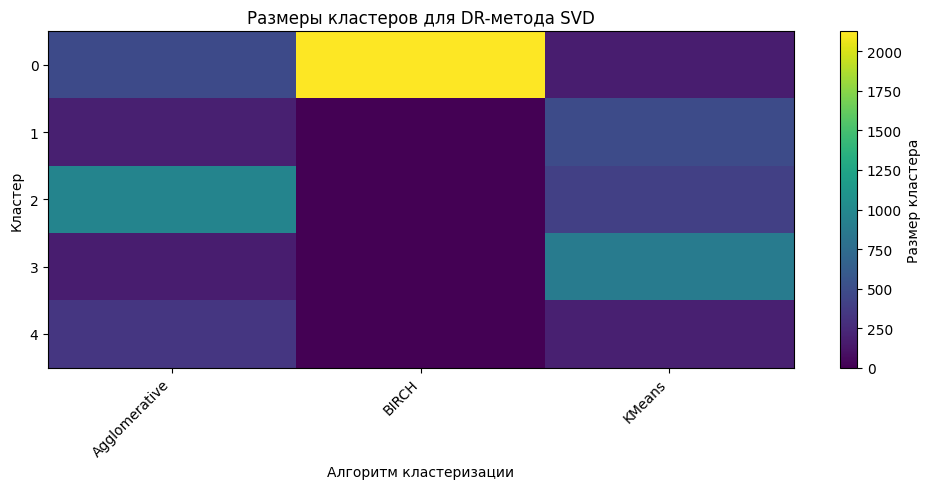

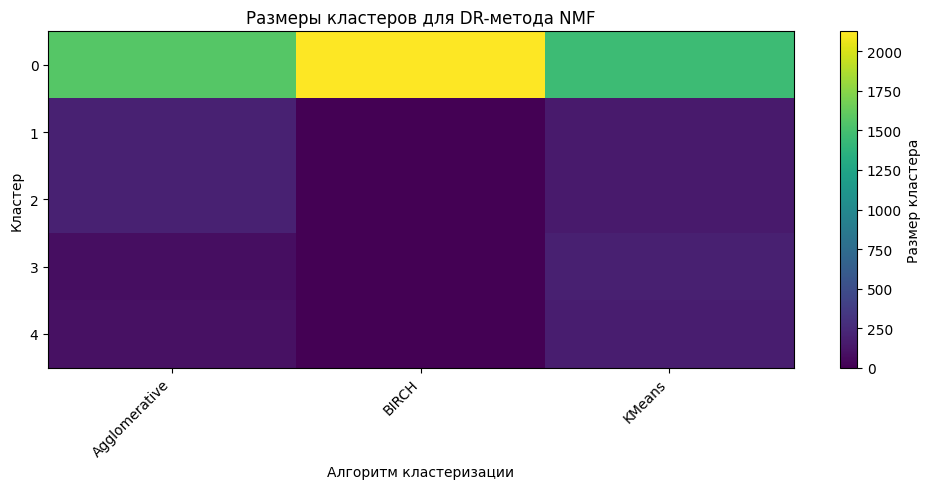

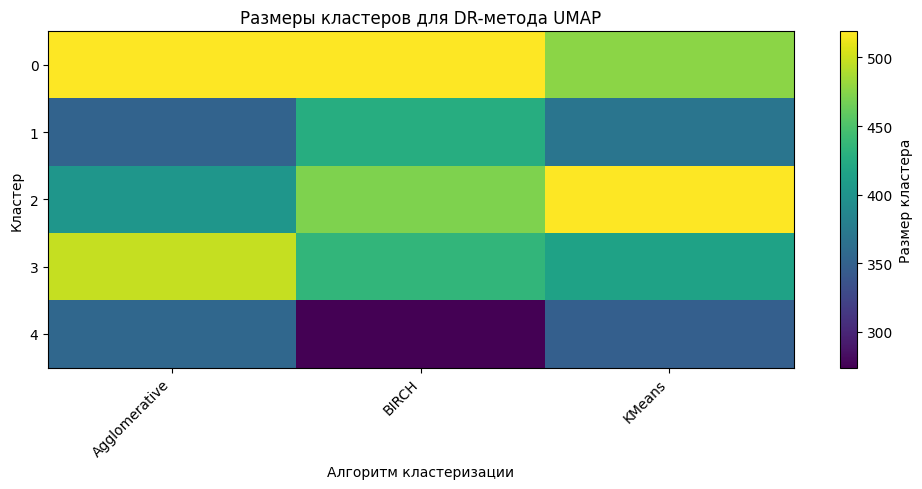

In [43]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import contingency_matrix



if "summary_df" in globals():
    comparison_df = summary_df.copy()
elif "results_df" in globals():
    comparison_df = results_df.copy()
elif "ranked_results" in globals():
    comparison_df = ranked_results.copy()
else:
    raise ValueError("Не найдена таблица результатов: summary_df / results_df / ranked_results")

if "Algorithm" not in comparison_df.columns and "Clustering" in comparison_df.columns:
    comparison_df = comparison_df.rename(columns={"Clustering": "Algorithm"})

if "DR_Method" not in comparison_df.columns:
    raise ValueError("В таблице результатов должен быть столбец DR_Method")

if "Algorithm" not in comparison_df.columns:
    raise ValueError("В таблице результатов должен быть столбец Algorithm или Clustering")

metric_cols = [
    "Silhouette",
    "Calinski_Harabasz",
    "Davies_Bouldin",
    "ARI",
    "AMI",
    "V_Measure"
]

metric_cols = [m for m in metric_cols if m in comparison_df.columns]

print("Используемые метрики:", metric_cols)
display(comparison_df.head())


# ---------- 1. Рейтинг пайплайнов по всем метрикам ----------

rank_df = comparison_df.copy()

positive_metrics = [
    "Silhouette",
    "Calinski_Harabasz",
    "ARI",
    "AMI",
    "V_Measure"
]

negative_metrics = [
    "Davies_Bouldin"
]

used_metrics = []

for metric in metric_cols:
    values = rank_df[metric].astype(float)

    min_val = values.min()
    max_val = values.max()

    if max_val == min_val:
        rank_df[metric + "_norm"] = 0.5
    else:
        if metric in negative_metrics:
            rank_df[metric + "_norm"] = (max_val - values) / (max_val - min_val)
        else:
            rank_df[metric + "_norm"] = (values - min_val) / (max_val - min_val)

    used_metrics.append(metric + "_norm")

rank_df["Mean_Normalized_Score"] = rank_df[used_metrics].mean(axis=1)

rank_df = rank_df.sort_values("Mean_Normalized_Score", ascending=False)

print("Рейтинг пайплайнов по средней нормализованной оценке:")
display(
    rank_df[
        ["DR_Method", "Algorithm"] + metric_cols + ["Mean_Normalized_Score"]
    ].round(4)
)


# ---------- 2. Heatmap итоговой нормализованной оценки ----------

score_pivot = rank_df.pivot(
    index="DR_Method",
    columns="Algorithm",
    values="Mean_Normalized_Score"
)

plt.figure(figsize=(10, 6))
plt.imshow(score_pivot, aspect="auto")
plt.colorbar(label="Mean Normalized Score")

plt.xticks(
    ticks=np.arange(len(score_pivot.columns)),
    labels=score_pivot.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=np.arange(len(score_pivot.index)),
    labels=score_pivot.index
)

for i in range(score_pivot.shape[0]):
    for j in range(score_pivot.shape[1]):
        value = score_pivot.iloc[i, j]
        if not pd.isna(value):
            plt.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                color="white" if value < score_pivot.max().max() * 0.65 else "black"
            )

plt.title("Сравнение пайплайнов по комплексной нормализованной оценке")
plt.xlabel("Алгоритм кластеризации")
plt.ylabel("Метод понижения размерности")
plt.tight_layout()
plt.show()


# ---------- 3. Топ пайплайнов: barplot ----------

top_n = min(10, len(rank_df))
top_df = rank_df.head(top_n).copy()
top_df["Pipeline"] = top_df["DR_Method"] + " → " + top_df["Algorithm"]

plt.figure(figsize=(10, 5))
plt.barh(top_df["Pipeline"][::-1], top_df["Mean_Normalized_Score"][::-1])
plt.xlabel("Mean Normalized Score")
plt.ylabel("Пайплайн")
plt.title("Топ пайплайнов DR → кластеризация")
plt.tight_layout()
plt.show()


# ---------- 4. Radar chart для топ-5 пайплайнов ----------

radar_metrics = [
    m for m in [
        "Silhouette_norm",
        "Calinski_Harabasz_norm",
        "Davies_Bouldin_norm",
        "ARI_norm",
        "AMI_norm",
        "V_Measure_norm"
    ]
    if m in rank_df.columns
]

radar_labels = [m.replace("_norm", "") for m in radar_metrics]

top_radar = rank_df.head(min(5, len(rank_df))).copy()

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for _, row in top_radar.iterrows():
    values = row[radar_metrics].values.astype(float).tolist()
    values += values[:1]

    label = f"{row['DR_Method']} → {row['Algorithm']}"
    ax.plot(angles, values, linewidth=2, label=label)
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)
ax.set_ylim(0, 1)
ax.set_title("Сравнение топ-5 пайплайнов по нормализованным метрикам", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.45, 1.10))
plt.tight_layout()
plt.show()


# ---------- 5. Сравнение количества найденных кластеров ----------

if "N_Clusters" in comparison_df.columns:
    clusters_pivot = comparison_df.pivot(
        index="DR_Method",
        columns="Algorithm",
        values="N_Clusters"
    )

    plt.figure(figsize=(10, 6))
    plt.imshow(clusters_pivot, aspect="auto")
    plt.colorbar(label="Количество кластеров")

    plt.xticks(
        ticks=np.arange(len(clusters_pivot.columns)),
        labels=clusters_pivot.columns,
        rotation=45,
        ha="right"
    )
    plt.yticks(
        ticks=np.arange(len(clusters_pivot.index)),
        labels=clusters_pivot.index
    )

    for i in range(clusters_pivot.shape[0]):
        for j in range(clusters_pivot.shape[1]):
            value = clusters_pivot.iloc[i, j]
            if not pd.isna(value):
                plt.text(
                    j,
                    i,
                    f"{int(value)}",
                    ha="center",
                    va="center",
                    color="white"
                )

    plt.title("Сравнение количества найденных кластеров")
    plt.xlabel("Алгоритм кластеризации")
    plt.ylabel("Метод понижения размерности")
    plt.tight_layout()
    plt.show()


# ---------- 6. Сравнение методов DR по средним значениям метрик ----------

dr_mean = comparison_df.groupby("DR_Method")[metric_cols].mean()

display(dr_mean.round(4))

for metric in metric_cols:
    plt.figure(figsize=(8, 4))
    values = dr_mean[metric].sort_values(ascending=False)

    plt.bar(values.index, values.values)
    plt.title(f"Среднее значение {metric} по DR-методам")
    plt.xlabel("DR-метод")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ---------- 7. Сравнение алгоритмов кластеризации по средним значениям метрик ----------

algo_mean = comparison_df.groupby("Algorithm")[metric_cols].mean()

display(algo_mean.round(4))

for metric in metric_cols:
    plt.figure(figsize=(8, 4))
    values = algo_mean[metric].sort_values(ascending=False)

    plt.bar(values.index, values.values)
    plt.title(f"Среднее значение {metric} по алгоритмам кластеризации")
    plt.xlabel("Алгоритм")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ---------- 8. Попарная похожесть кластеризаций через ARI ----------

if "cluster_labels" in globals():
    labels_dict = cluster_labels
elif "all_labels" in globals():
    labels_dict = all_labels
elif "all_results" in globals():
    labels_dict = {}

    for key, value in all_results.items():
        if isinstance(value, dict) and "labels" in value:
            labels_dict[key] = value["labels"]
else:
    labels_dict = None

if labels_dict is not None:
    pipeline_names = []
    labels_list = []

    for key, labels in labels_dict.items():
        if labels is None:
            continue

        if isinstance(key, tuple):
            name = " → ".join(map(str, key))
        else:
            name = str(key)

        labels = np.asarray(labels)

        if len(labels) > 0:
            pipeline_names.append(name)
            labels_list.append(labels)

    min_len = min(len(x) for x in labels_list)

    ari_matrix = np.zeros((len(labels_list), len(labels_list)))

    for i in range(len(labels_list)):
        for j in range(len(labels_list)):
            ari_matrix[i, j] = adjusted_rand_score(
                labels_list[i][:min_len],
                labels_list[j][:min_len]
            )

    plt.figure(figsize=(12, 10))
    plt.imshow(ari_matrix, vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(label="ARI между кластеризациями")

    plt.xticks(
        ticks=np.arange(len(pipeline_names)),
        labels=pipeline_names,
        rotation=90
    )
    plt.yticks(
        ticks=np.arange(len(pipeline_names)),
        labels=pipeline_names
    )

    plt.title("Попарная похожесть результатов кластеризации между пайплайнами")
    plt.tight_layout()
    plt.show()

    ari_pairwise_df = pd.DataFrame(
        ari_matrix,
        index=pipeline_names,
        columns=pipeline_names
    )

    display(ari_pairwise_df.round(3))


# ---------- 9. Матрица соответствия кластеров и истинных классов для лучшего пайплайна ----------

if "y" in globals() and labels_dict is not None:
    best_pipeline = rank_df.iloc[0]
    best_dr = best_pipeline["DR_Method"]
    best_algo = best_pipeline["Algorithm"]

    possible_keys = [
        (best_dr, best_algo),
        (best_dr, str(best_algo)),
        (str(best_dr), str(best_algo)),
        f"{best_dr} → {best_algo}",
        f"{best_dr}_{best_algo}",
        f"{best_dr}-{best_algo}"
    ]

    best_labels = None

    for key in possible_keys:
        if key in labels_dict:
            best_labels = np.asarray(labels_dict[key])
            break

    if best_labels is None:
        for key, value in labels_dict.items():
            key_text = str(key)
            if best_dr in key_text and best_algo in key_text:
                best_labels = np.asarray(value)
                break

    if best_labels is not None:
        y_arr = np.asarray(y)
        min_len = min(len(y_arr), len(best_labels))

        y_part = y_arr[:min_len]
        labels_part = best_labels[:min_len]

        cm = contingency_matrix(y_part, labels_part)

        plt.figure(figsize=(9, 6))
        plt.imshow(cm, aspect="auto")
        plt.colorbar(label="Количество объектов")

        plt.xlabel("Номер кластера")
        plt.ylabel("Истинный класс")
        plt.title(f"Матрица соответствия: {best_dr} → {best_algo}")

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(
                    j,
                    i,
                    str(cm[i, j]),
                    ha="center",
                    va="center",
                    color="white" if cm[i, j] < cm.max() * 0.6 else "black"
                )

        plt.tight_layout()
        plt.show()

        composition = pd.crosstab(
            pd.Series(labels_part, name="Cluster"),
            pd.Series(y_part, name="True_Class"),
            normalize="index"
        ) * 100

        print(f"Процентный состав кластеров для лучшего пайплайна: {best_dr} → {best_algo}")
        display(composition.round(2))


# ---------- 10. Размеры кластеров по пайплайнам ----------

if labels_dict is not None:
    cluster_size_rows = []

    for key, labels in labels_dict.items():
        labels = np.asarray(labels)

        if isinstance(key, tuple) and len(key) >= 2:
            dr_name = key[0]
            algo_name = key[1]
        else:
            key_text = str(key)
            if "→" in key_text:
                dr_name, algo_name = [part.strip() for part in key_text.split("→", 1)]
            else:
                dr_name = key_text
                algo_name = "Unknown"

        unique, counts = np.unique(labels, return_counts=True)

        for cluster_id, size in zip(unique, counts):
            cluster_size_rows.append({
                "DR_Method": dr_name,
                "Algorithm": algo_name,
                "Cluster": cluster_id,
                "Size": size
            })

    cluster_sizes_df = pd.DataFrame(cluster_size_rows)

    display(cluster_sizes_df.head())

    for dr_name in cluster_sizes_df["DR_Method"].unique():
        temp = cluster_sizes_df[cluster_sizes_df["DR_Method"] == dr_name]

        pivot_sizes = temp.pivot_table(
            index="Cluster",
            columns="Algorithm",
            values="Size",
            fill_value=0
        )

        plt.figure(figsize=(10, 5))
        plt.imshow(pivot_sizes, aspect="auto")
        plt.colorbar(label="Размер кластера")

        plt.xticks(
            ticks=np.arange(len(pivot_sizes.columns)),
            labels=pivot_sizes.columns,
            rotation=45,
            ha="right"
        )
        plt.yticks(
            ticks=np.arange(len(pivot_sizes.index)),
            labels=pivot_sizes.index
        )

        plt.title(f"Размеры кластеров для DR-метода {dr_name}")
        plt.xlabel("Алгоритм кластеризации")
        plt.ylabel("Кластер")
        plt.tight_layout()
        plt.show()

In [32]:
def run_to_run_stability(
    X,
    y_true,
    dr_method,
    cluster_method,
    n_clusters,
    n_runs=5,
    sample_frac=0.8,
    n_components=10
):
    runs = []
    external_ari_scores = []

    n_samples = X.shape[0]
    sample_size = int(n_samples * sample_frac)

    for run in range(n_runs):
        rng = np.random.default_rng(RANDOM_STATE + run)

        indices = rng.choice(
            n_samples,
            size=sample_size,
            replace=False
        )

        X_sub = X[indices]
        y_sub = y_true[indices]

        Z_sub, _ = reduce_dimensions(
            X_sub,
            method=dr_method,
            n_components=n_components,
            random_state=RANDOM_STATE + run
        )

        labels_sub, _ = cluster_embedding(
            Z_sub,
            algorithm=cluster_method,
            n_clusters=n_clusters,
            random_state=RANDOM_STATE + run
        )

        runs.append((indices, labels_sub))
        external_ari_scores.append(adjusted_rand_score(y_sub, labels_sub))

    pairwise_ari = []

    for i in range(len(runs)):
        for j in range(i + 1, len(runs)):
            idx_i, labels_i = runs[i]
            idx_j, labels_j = runs[j]

            common, pos_i, pos_j = np.intersect1d(
                idx_i,
                idx_j,
                return_indices=True
            )

            if len(common) > 10:
                ari = adjusted_rand_score(
                    labels_i[pos_i],
                    labels_j[pos_j]
                )
                pairwise_ari.append(ari)

    return {
        "Stability_ARI_Mean": np.mean(pairwise_ari),
        "Stability_ARI_Std": np.std(pairwise_ari),
        "External_ARI_Mean": np.mean(external_ari_scores),
        "External_ARI_Std": np.std(external_ari_scores)
    }


stability_results = []

top_pipelines = ranked_results.head(5)

for _, row in top_pipelines.iterrows():
    dr_name = row["DR_Method"]
    cluster_name = row["Clustering"]

    print(f"Анализ устойчивости: {dr_name} → {cluster_name}")

    stability = run_to_run_stability(
        X,
        y,
        dr_name,
        cluster_name,
        n_clusters=n_clusters,
        n_runs=5,
        sample_frac=0.8,
        n_components=n_components
    )

    stability_results.append({
        "DR_Method": dr_name,
        "Clustering": cluster_name,
        **stability
    })

stability_df = pd.DataFrame(stability_results)
stability_df.round(4)

Анализ устойчивости: UMAP → KMeans
Анализ устойчивости: UMAP → Agglomerative
Анализ устойчивости: UMAP → BIRCH
Анализ устойчивости: SVD → KMeans
Анализ устойчивости: SVD → Agglomerative


,DR_Method,Clustering,Stability_ARI_Mean,Stability_ARI_Std,External_ARI_Mean,External_ARI_Std
0,UMAP,KMeans,0.7684,0.1004,0.7053,0.0997
1,UMAP,Agglomerative,0.7664,0.1070,0.6976,0.0945
2,UMAP,BIRCH,0.7763,0.0773,0.7131,0.0927
3,SVD,KMeans,0.6735,0.2091,0.5124,0.0468
4,SVD,Agglomerative,0.6853,0.1207,0.5979,0.1467


In [33]:
def top_terms_per_cluster(X_tfidf, labels, feature_names, top_n=12):
    rows = []

    for cluster_id in sorted(np.unique(labels)):
        cluster_mask = labels == cluster_id

        if cluster_mask.sum() == 0:
            continue

        mean_tfidf = np.asarray(
            X_tfidf[cluster_mask].mean(axis=0)
        ).ravel()

        top_indices = mean_tfidf.argsort()[::-1][:top_n]
        top_terms = feature_names[top_indices]

        rows.append({
            "Cluster": cluster_id,
            "Size": cluster_mask.sum(),
            "Top_Terms": ", ".join(top_terms)
        })

    return pd.DataFrame(rows)


interpretation_df = top_terms_per_cluster(
    X,
    best_labels,
    feature_names,
    top_n=15
)

interpretation_df

,Cluster,Size,Top_Terms
0,0,476,"growth, bank, economy, market, company, year, ..."
1,1,369,"film, best, music, awards, award, band, festiv..."
2,2,519,"game, england, win, cup, club, match, team, pl..."
3,3,415,"mr, labour, election, blair, party, government..."
4,4,348,"mobile, people, games, technology, users, soft..."


In [36]:
cluster_composition = pd.crosstab(
    pd.Series(best_labels, name="Cluster"),
    pd.Series(df["label"].values, name="True_Label"),
    normalize="index"
) * 100

cluster_composition.round(2)

True_Label,business,entertainment,politics,sport,tech
Cluster,,,,,
0,92.86,0.84,4.41,0.42,1.47
1,0.81,92.95,1.36,0.00,4.88
2,2.12,0.58,0.77,96.34,0.19
3,6.99,2.65,88.67,0.72,0.96
4,5.17,2.30,1.44,0.00,91.09


In [45]:
nmf_topic_model = NMF(
    n_components=n_clusters,
    init="nndsvda",
    random_state=RANDOM_STATE,
    max_iter=500
)

W = nmf_topic_model.fit_transform(X)
H = nmf_topic_model.components_

# Для каждого документа определяем наиболее выраженную NMF-тему
document_topics = W.argmax(axis=1)

# Преобразуем числовые y обратно в реальные названия классов
if "label_encoder" in globals():
    real_labels = label_encoder.inverse_transform(y)
elif "target_names" in globals():
    real_labels = np.array(target_names)[y]
else:
    real_labels = df["label"].values

topics = []

for topic_idx, topic_vector in enumerate(H):
    top_indices = topic_vector.argsort()[::-1][:15]
    top_terms = feature_names[top_indices]

    topic_mask = document_topics == topic_idx
    topic_size = topic_mask.sum()

    if topic_size > 0:
        class_counts = pd.Series(real_labels[topic_mask]).value_counts()
        dominant_class = class_counts.index[0]
        dominant_class_count = class_counts.iloc[0]
        purity = dominant_class_count / topic_size
    else:
        dominant_class = "Нет документов"
        dominant_class_count = 0
        purity = 0

    topics.append({
        "NMF_Topic": topic_idx,
        "Real_Class": dominant_class,
        "Topic_Size": topic_size,
        "Class_Objects": dominant_class_count,
        "Purity": purity,
        "Top_Terms": ", ".join(top_terms)
    })

topics_df = pd.DataFrame(topics)

topics_df = topics_df.sort_values(
    by=["Real_Class", "Purity"],
    ascending=[True, False]
).reset_index(drop=True)

topics_df

,NMF_Topic,Real_Class,Topic_Size,Class_Objects,Purity,Top_Terms
0,2,business,499,465,0.931864,"growth, economy, sales, year, bank, oil, econo..."
1,3,entertainment,308,299,0.970779,"film, best, awards, award, festival, actor, fi..."
2,1,politics,388,362,0.932990,"mr, labour, election, blair, brown, party, mr ..."
3,0,sport,505,498,0.986139,"england, game, win, wales, cup, ireland, play,..."
4,4,tech,427,338,0.791569,"mobile, people, music, phone, technology, digi..."


## Итоговые выводы

В проекте был исследован высокоразмерный текстовый датасет BBC Articles / BBC News. 
После TF-IDF-векторизации тексты были представлены в виде разреженных векторов большой размерности. 
Это позволило рассматривать задачу как типичный пример анализа высокоразмерных данных.

Были построены и сравнены пайплайны вида:

**DR-метод → алгоритм кластеризации**

Использованные методы понижения размерности:

1. **TruncatedSVD** — линейный метод, хорошо подходящий для разреженных TF-IDF-матриц.
2. **NMF** — неотрицательная матричная факторизация, полезная для тематической интерпретации текстов.
3. **UMAP** — нелинейный метод, ориентированный на сохранение локальной структуры данных.

Использованные алгоритмы кластеризации:

1. **KMeans**
2. **Agglomerative Clustering**
3. **BIRCH**

Качество оценивалось с помощью внутренних и внешних метрик:

- Silhouette Score;
- Calinski-Harabasz Score;
- Davies-Bouldin Score;
- Adjusted Rand Index;
- Adjusted Mutual Information;
- V-measure.

Дополнительно была рассчитана комплексная взвешенная метрика, объединяющая несколько показателей.
Это позволило сравнивать пайплайны не по одной метрике, а по совокупному качеству.

Анализ устойчивости показал, насколько результаты сохраняются при случайных подвыборках данных.
Для этого использовался run-to-run bootstrap-анализ и попарный ARI между кластеризациями на пересекающихся объектах.

Интерпретируемость кластеров оценивалась через:

- ключевые TF-IDF-термины внутри каждого кластера;
- распределение реальных тематических меток внутри кластеров;
- NMF-темы и их наиболее важные слова.

В целом для текстовых данных наиболее интерпретируемым оказался подход на основе NMF,
так как компоненты NMF можно напрямую связать с наборами ключевых слов.
TruncatedSVD обычно работает быстрее и стабильнее, а UMAP может лучше показывать локальные группы,
но его результаты сильнее зависят от гиперпараметров и случайной инициализации.